In [49]:
import numpy as np
import os
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import pandas as pd
from scipy.optimize import curve_fit

img_path = f'/home/kale-chen/Documents/CASToR/images/'

In [91]:
# Data contatenator
datadir = '/home/kale-chen/Documents/PET/TPPT2026/data/'
dataname = 'htofpgd'
outname = 'tofpair'
for i in range(1, 6):
    data1 = np.fromfile(os.path.join(datadir, f'{dataname}0.bin'), dtype = np.int16)
    data2 = np.fromfile(os.path.join(datadir, f'{dataname}{i}.bin'), dtype = np.int16)
    combined_data = np.concatenate((data1, data2))
    if os.path.exists(os.path.join(datadir, f'{outname}{i}.bin')):
        os.remove(os.path.join(datadir, f'{outname}{i}.bin'))
    combined_data.tofile(os.path.join(datadir, f'{outname}{i}.bin'))


In [105]:
n = 5
datanames = ['htofpgd0', f'htofpgd{n}', f'tofpair{n}']
cal = True
num_cols = 4
mapdf = pd.read_csv('/home/kale-chen/Documents/PET/TPPT_Scanner_map_adjusted.csv', usecols=[0,1,2,3,4,5], header=None)
map = mapdf.to_numpy()[:, 0:3]
acceptedL = ((map[:,1] < 6) & (map[:,1] > -6))[3072:]
acceptedR = ((map[:,1] < 6) & (map[:,1] > -6))[:3072]
print(np.sum(acceptedL), np.sum(acceptedR))
time_offsets_file = '/home/kale-chen/Documents/PET/TimeCalibration/CalibrationDataPreparer/tsvs/time_offset_calibrationit10.tsv'
time_offsets = np.genfromtxt(time_offsets_file, delimiter = '\t')[:, 4]
timediffs = []
for dataname in datanames:
    num_rows = os.path.getsize(os.path.join(datadir, f'{dataname}.bin')) // (num_cols * 2)
    data = np.memmap(os.path.join(datadir, f'{dataname}.bin'), dtype = np.int16, shape = (num_rows, num_cols))
    writehead = 0
    timediff = np.zeros(num_rows)
    for i in range(0, num_rows, 1000000):
        chunk = data[i:i+1000000]
        chunk = chunk[acceptedL[chunk[:,0]] & acceptedR[chunk[:,1]]]
        if cal:
            timediff[writehead:writehead+len(chunk)] = chunk[:,2] - time_offsets[chunk[:,0] + 3072] + time_offsets[chunk[:,1]]
        else:
            timediff[writehead:writehead+len(chunk)] = chunk[:,2]
        writehead += len(chunk)
    timediffs.append(timediff[:writehead])
    print(writehead)


128 128
47958
32006
79964


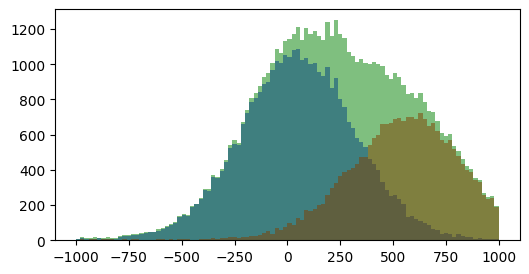

In [106]:
def gaussian(x, a, b, c):
    return a * np.exp(-(x - b)**2 / (2 * c**2))
bins = np.linspace(-1000, 1000, 101)
bincenters = (bins[1:] + bins[:-1]) / 2
plt.figure(figsize = (6, 3))
hist1 = plt.hist(timediffs[0], bins = bins, alpha = 0.5, color = 'blue')[0]
hist2 = plt.hist(timediffs[1], bins = bins, alpha = 0.5, color = 'red')[0]
hist3 = plt.hist(timediffs[2], bins = bins, alpha = 0.5, color = 'green')[0]
if False:
    popt, _ = curve_fit(gaussian, bincenters, hist, p0 = [1000, 0, 300])
    plottingspace = np.linspace(popt[1] - 3 * popt[2], popt[1] + 3 * popt[2], 1000)
    plt.plot(plottingspace, gaussian(plottingspace, *popt), color = 'black', linewidth = 1)
    print(popt)
plt.show()

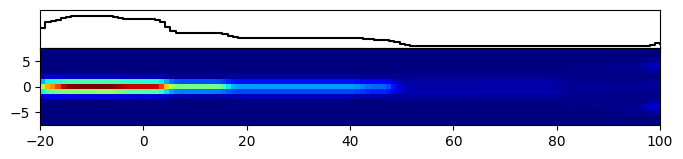

In [245]:
name = 'tofpair1n'
#name = 'htofpgd2nt'
dim = (120, 15, 100)
vox = (1, 1, 1)
offset = 0

fig = plt.figure(0, figsize = (8, 1.5))
gs = GridSpec(2, 1, height_ratios=[1, 2], hspace = 0)
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1], sharex = ax1)

img = np.fromfile(os.path.join(img_path, name, f'{name}_it{1}.img'), dtype = np.float32).reshape(dim, order = 'F')
img = np.flip(img, axis=1)
img = np.flip(img, axis=2)
imgxy = img.sum(axis = 2)
imgx = imgxy.sum(axis = 1)

ax1.step(np.linspace(-20+offset, 100+offset, dim[0]), imgx, where = 'post', color = 'black')
ax1.set_yticks([])
ax1.set_ylim(0, np.max(imgx) * 1.2)
ax2.imshow(imgxy.T, cmap = 'jet', extent = [-20 + offset, 100 + offset, -7.5, 7.5], aspect = 'auto')
plt.setp(ax1.get_xticklabels(), visible=False)
plt.show()


In [ ]:

tags = ['1', '1n', '2', '2n']
ratios = [[] for _ in range(len(tags))]
for t in range(len(tags)):
    name1, name2 = name1i + tags[t], name2i + tags[t]
    for it in range(1, 11):
        if '1' in name1:
            dim = (20, 20, 100)
            vox = (1, 1, 1)
            bounds1 = [(1, 19), (8, 14), (0, dim[2])]
            bounds2 = [(1, 19), (3, 12), (0, dim[2])]
        else:
            dim = (10, 10, 50)
            vox = (2, 2, 2)
            bounds1 = [(1, 9), (4, 8), (0, dim[2])]
            bounds2 = [(1, 9), (1, 6), (0, dim[2])]
        print(dim, vox, bounds1, bounds2)

        img1 = np.fromfile(os.path.join(img_path, name1, f'{name1}_it{it}.img'), dtype = np.float32).reshape(dim, order = 'F')
        img1 = np.flip(img1, axis=1)
        img1 = np.flip(img1, axis=2)
        img2 = np.fromfile(os.path.join(img_path, name2, f'{name2}_it{it}.img'), dtype = np.float32).reshape(dim, order = 'F')
        img2 = np.flip(img2, axis=1)
        img2 = np.flip(img2, axis=2)
        print(np.mean(img1), np.mean(img2), (np.sum(img1) / np.sum(img2)))
        extenty = (-dim[1] * vox[1] / 2, dim[1] * vox[1] / 2)
        extentz = (-dim[2] * vox[2] / 2, dim[2] * vox[2] / 2)
        slices1, slices2 = [], []
        for i in range(bounds1[2][1] - bounds1[2][0]):
            slices1.append(img1[bounds1[0][0]:bounds1[0][1], bounds1[1][0]:bounds1[1][1], i].sum())
        for i in range(bounds2[2][1] - bounds2[2][0]):
            slices2.append(img2[bounds2[0][0]:bounds2[0][1], bounds2[1][0]:bounds2[1][1], i].sum())
        slices1.insert(0, slices1[0])
        slices2.insert(0, slices2[0])
        slices1 = np.array(slices1)
        slices2 = np.array(slices2)
        #print(len(slices1), len(slices2))
        plotsheight = 6
        heatmapwidth = (dim[1] * vox[1]) / (dim[2] * vox[2]) * plotsheight
        plotswidth = 4 * heatmapwidth + 0.4
        #print(plotswidth, plotsheight)
        fig, ax = plt.subplots(1, 3, figsize = (plotswidth, plotsheight), width_ratios = [1, 1, 2], sharey=True)
        collapsex1 = img1.sum(axis = 0)
        collapsex2 = img2.sum(axis = 0)
        vmin, vmax = min(np.min(collapsex1), np.min(collapsex2)), max(np.max(collapsex1), np.max(collapsex2))
        print(vmin, vmax)
        vmax = 0.9 * vmax
        ax[0].imshow(collapsex1.T, cmap = 'jet', extent = [extenty[0], extenty[1], extentz[0], extentz[1]], vmin = vmin, vmax = vmax)
        ax[1].imshow(collapsex2.T, cmap = 'jet', extent = [extenty[0], extenty[1], extentz[0], extentz[1]], vmin = vmin, vmax = vmax)
        ax[0].set_ylim(extentz[0], extentz[1])
        cutimg1 = img1[bounds1[0][0]:bounds1[0][1], bounds1[1][0]:bounds1[1][1], bounds1[2][0]:bounds1[2][1]]
        cutimg2 = img2[bounds2[0][0]:bounds2[0][1], bounds2[1][0]:bounds2[1][1], bounds2[2][0]:bounds2[2][1]]
        ax[2].step(slices1 / np.mean(slices1), np.linspace(extentz[1], extentz[0], bounds1[2][1] - bounds1[2][0] + 1), where = 'post', color = 'blue', 
            label = f'hcenter\nIntegrated activity: {np.sum(cutimg1) / 600:.5f}')
        ax[2].step(slices2 / np.mean(slices2), np.linspace(extentz[1], extentz[0], bounds2[2][1] - bounds2[2][0] + 1), where = 'post', color = 'red', 
            label = f'mcenter\nIntegrated activity: {np.sum(cutimg2) / 600:.5f}')
        print(np.std(slices1 / np.mean(slices1)), np.std(slices2 / np.mean(slices2)))
        ax[0].vlines(-dim[1] * vox[1] / 2 + bounds1[1][0] * vox[1], extentz[0], extentz[1], color = 'red', linestyle = '--', linewidth = 0.5)
        ax[0].vlines(-dim[1] * vox[1] / 2 + bounds1[1][1] * vox[1], extentz[0], extentz[1], color = 'red', linestyle = '--', linewidth = 0.5)
        ax[1].vlines(-dim[1] * vox[1] / 2 + bounds2[1][0] * vox[1], extentz[0], extentz[1], color = 'red', linestyle = '--', linewidth = 0.5)
        ax[1].vlines(-dim[1] * vox[1] / 2 + bounds2[1][1] * vox[1], extentz[0], extentz[1], color = 'red', linestyle = '--', linewidth = 0.5)
        ax[0].set_xlabel('y (mm)')
        ax[0].set_ylabel('z (mm)')
        ax[1].set_xlabel('y (mm)')
        ax[0].set_title('hcenter')
        ax[1].set_title('mcenter')
        ax[2].set_title('')
        ax[2].set_xlabel('Intensity scaled to mean')
        ax[2].plot([0], [0], linewidth = 0, label = f'Activity ratio = {np.sum(cutimg1) / np.sum(cutimg2):.3f}')
        ax[2].legend(fontsize = 8, framealpha = 0.8, loc = 'upper right')
        ax[2].set_xlim(0.8, 1.2)
        title = 'Normalized, ' if name1[-1] == 'n' else 'Unnormalized, '
        title = title + '1mm voxel' if '1' in name1 else title + '2mm voxel'
        title = title + f', it{it}'
        plt.suptitle(title)
        plt.subplots_adjust(hspace=0, wspace=0.1) # Spacing
        plt.savefig(f'/home/kale-chen/Documents/PET/Sensitivity Normalization/writeup/plots/activityrecon/{tags[t]}it{it}.pdf', format="pdf", dpi=300, bbox_inches="tight")
        plt.show()
        ratios[t].append(np.sum(cutimg1) / np.sum(cutimg2))
